# CNN on Fashion-MNIST

In this exercise, you will build and investigate a **Convolutional Neural Network (CNN)** for image classification using the Fashion-MNIST dataset. The exercise is designed to be completed within 60 minutes. The code to be completed is explicitly marked as #🎯 TODO

Rather than focusing only on achieving a high accuracy, the goal is to understand **how different design and training choices affect a CNN and its predictions**.

You will work through the exercise step by step:

### 1. Prepare the data

You will load the Fashion-MNIST dataset and create separate **training, validation, and test sets**. You will also introduce **data augmentation** to create slightly different versions of training images.

### 2. Inspect the augmented images

Before training the model, you will visualize some of the augmented images and see what the CNN actually receives during training.

### 3. Build a deeper CNN

You will use a CNN with several convolutional blocks. The architecture includes:

* convolutional layers;
* batch normalization;
* ReLU activations;
* max pooling;
* dropout;
* fully connected layers.

These components allow the model to learn increasingly complex visual features while helping to control overfitting.

### 4. Train the model

You will train the CNN using the training set while monitoring its performance on the validation set.

During training, you will track:

* training loss and accuracy;
* validation loss and accuracy;
* the best validation accuracy.

The model with the best validation performance is retained rather than simply using the model from the final training epoch.

### 5. Analyze the training process

You will plot the **training and validation curves** and use them to look for signs of overfitting.

The important question is not just:

> "How accurate is the model?"

but also:

> "What happened during training, and what can we learn from the training and validation curves?"

### 6. Evaluate on unseen data

Only after model selection will you evaluate the final model on the **test set**.

This gives you an estimate of how well the trained CNN generalizes to images it has not seen during training.

### 7. Inspect individual predictions

You will visualize several test images together with the model's predictions.

Correct predictions and incorrect predictions are highlighted differently, allowing you to inspect examples where the CNN succeeds or fails.

### 8. Analyze the confusion matrix

Accuracy gives us a single number, but it does not tell us **which classes are difficult for the model**.

You will therefore create a confusion matrix and investigate:

* which classes are recognized most accurately;
* which classes are frequently confused;
* why some clothing categories may be visually difficult to distinguish.

### 9. Look inside the CNN

Finally, you will visualize feature maps produced by the first convolutional layer.

This gives you a first look at how a CNN transforms an input image into learned visual representations.





---

## What you should focus on

By the end of the exercise, you should be able to connect the different parts of a CNN workflow:

**data → augmentation → architecture → training → validation → testing → error analysis → learned features**

The objective is not simply to train a CNN, but to develop an understanding of **why the model behaves the way it does**.


## Imports

In [1]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt


## Data

Fashion-MNIST contains 10 classes of 28×28 grayscale clothing images.

We use **data augmentation only for the training set**. Random rotations and horizontal flips create slightly different versions of training images and can help the model generalize better.

The validation and test sets are kept unchanged so that their results are comparable.

The following code loads and preprocesses the Fashion-MNIST dataset, applies data augmentation only to the training images, splits the data into training and validation sets, creates DataLoaders, and prints the size of each dataset.

In [2]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Two copies are used so that augmentation is applied only to training data.
full_train_aug = datasets.FashionMNIST('.', train=True, download=True, transform=train_transform)
full_train_eval = datasets.FashionMNIST('.', train=True, download=False, transform=eval_transform)
test_dataset = datasets.FashionMNIST('.', train=False, download=True, transform=eval_transform)

train_size = int(0.9 * len(full_train_aug))
val_size = len(full_train_aug) - train_size

generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(range(len(full_train_aug)), [train_size, val_size], generator=generator)

train_dataset = torch.utils.data.Subset(full_train_aug, train_indices.indices)
val_dataset = torch.utils.data.Subset(full_train_eval, val_indices.indices)

train = DataLoader(train_dataset, batch_size=64, shuffle=True)
val = DataLoader(val_dataset, batch_size=256)
test = DataLoader(test_dataset, batch_size=256)

print(f'Training images:   {len(train_dataset):,}')
print(f'Validation images: {len(val_dataset):,}')
print(f'Test images:       {len(test_dataset):,}')

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 165kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.08MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.9MB/s]

Training images:   54,000
Validation images: 6,000
Test images:       10,000


## Visualize the augmented data

The same original image can look slightly different after augmentation. This is what the CNN sees during training.

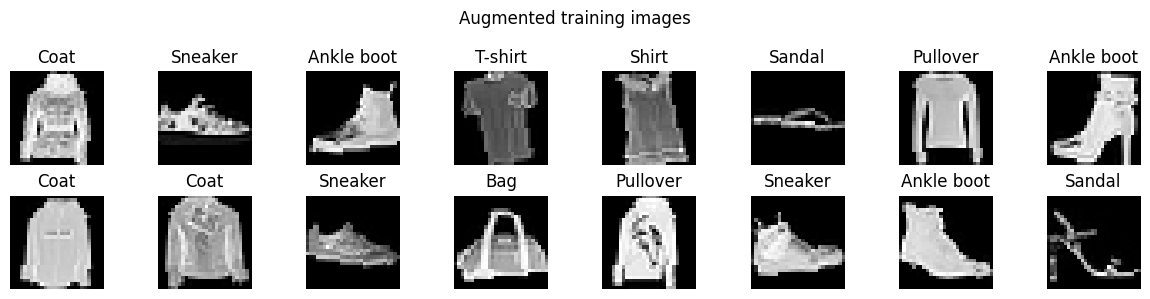

In [3]:
images, labels = next(iter(train))

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    image = images[i].squeeze() * 0.5 + 0.5  # undo normalization for display
    ax.imshow(image, cmap='gray')
    ax.set_title(class_names[labels[i]])
    ax.axis('off')
plt.suptitle('Augmented training images')
plt.tight_layout()
plt.show()

## Deeper CNN architecture
We now use **three convolutional blocks**, allowing the network to learn increasingly complex visual patterns from the images.

Each block contains:

* **Convolution:** learns filters that detect visual patterns such as edges, shapes, and textures. As we move deeper into the network, the filters can combine simpler patterns into more complex features.
* **Batch normalization:** normalizes the activations produced by the convolutional layer. This can make training more stable and help the network learn efficiently.
* **ReLU:** introduces a non-linear activation function, allowing the network to learn more complex relationships than would be possible with only linear operations.
* **Max pooling:** reduces the spatial size of the feature maps by keeping the strongest activations in small regions. This reduces the amount of computation and makes the learned features less sensitive to small changes in the exact location of an object.

Using **three blocks** means that the network can progressively transform the original image into higher-level representations. Earlier layers can learn simple features such as edges, while deeper layers can combine these into more meaningful patterns that help distinguish clothing categories.

We also use **dropout before the final classifier**. During training, dropout randomly sets some activations to zero. This prevents the network from relying too heavily on particular features and encourages it to learn more robust representations.



In [6]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 14x14 -> 7x7
            #🎯 TODO: complete the following code
            #Solution starts here
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 7x7 -> 3x3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
            #Solution ends here
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(),
            #🎯 TODO: Add dropout with a probability of 0.4
            nn.Dropout(0.4),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNN().to(device)

print(f'Device: {device}')
print(model)

Device: cuda
CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=128, bias=True)
    (2): ReLU()
    (3):

## Training

We keep track of both training and validation performance. The model with the **best validation accuracy** is saved and restored at the end.

This helps avoid simply training for longer and accidentally selecting an overfitted model.

In [7]:
#🎯 TODO: define the Adam optimizer with learning rate 1e-3 and weight decay 1e-4
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
#🎯 TODO: define the loss functon being the cross entropy loss
loss_fn = nn.CrossEntropyLoss()


epochs = 8
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_accuracy = 0.0
best_state = copy.deepcopy(model.state_dict())

def evaluate(model, loader):
    #🎯 TODO: switch to evaluation mode
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in train:
        x, y = x.to(device), y.to(device)
        #🎯 TODO: clear the gradients
        optimizer.zero_grad()
        #🎯 TODO: get the model logits
        logits = model(x)
        #🎯 TODO: calculate the loss
        loss = loss_fn(logits, y)
        #🎯 TODO: compute the gradients
        loss.backward()
        #🎯 TODO: update the model parameters
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total
    val_loss, val_accuracy = evaluate(model, val)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_state = copy.deepcopy(model.state_dict())

    print(
        f'Epoch {epoch + 1}/{epochs} | '
        f'train loss={train_loss:.3f}, train acc={train_accuracy:.3f} | '
        f'val loss={val_loss:.3f}, val acc={val_accuracy:.3f}'
    )

model.load_state_dict(best_state)
print(f'\nBest validation accuracy: {best_val_accuracy:.3f}')

Epoch 1/8 | train loss=0.530, train acc=0.810 | val loss=0.336, val acc=0.876
Epoch 2/8 | train loss=0.368, train acc=0.868 | val loss=0.308, val acc=0.889
Epoch 3/8 | train loss=0.325, train acc=0.883 | val loss=0.259, val acc=0.904
Epoch 4/8 | train loss=0.297, train acc=0.893 | val loss=0.272, val acc=0.901
Epoch 5/8 | train loss=0.286, train acc=0.897 | val loss=0.245, val acc=0.910
Epoch 6/8 | train loss=0.271, train acc=0.903 | val loss=0.228, val acc=0.914
Epoch 7/8 | train loss=0.260, train acc=0.906 | val loss=0.229, val acc=0.916
Epoch 8/8 | train loss=0.253, train acc=0.909 | val loss=0.222, val acc=0.919

Best validation accuracy: 0.919


## Training curves

Compare training and validation performance. A large and growing gap between the two can be a sign of overfitting.

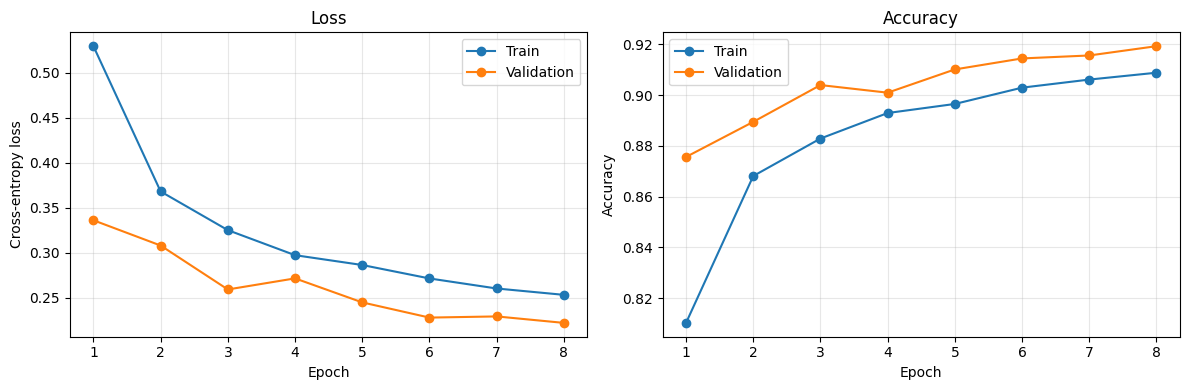

In [8]:
epochs_range = range(1, epochs + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(epochs_range, train_losses, marker='o', label='Train')
ax[0].plot(epochs_range, val_losses, marker='o', label='Validation')
ax[0].set_title('Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Cross-entropy loss')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(epochs_range, train_accuracies, marker='o', label='Train')
ax[1].plot(epochs_range, val_accuracies, marker='o', label='Validation')
ax[1].set_title('Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Final test evaluation

The test set is used only now, after model selection on the validation set.

In [9]:
test_loss, test_accuracy = evaluate(model, test)
print(f'Test loss:     {test_loss:.3f}')
print(f'Test accuracy: {test_accuracy:.3f}')

Test loss:     0.238
Test accuracy: 0.915


## Predictions

Green = correct prediction. Red = incorrect prediction. The true class is shown in parentheses.

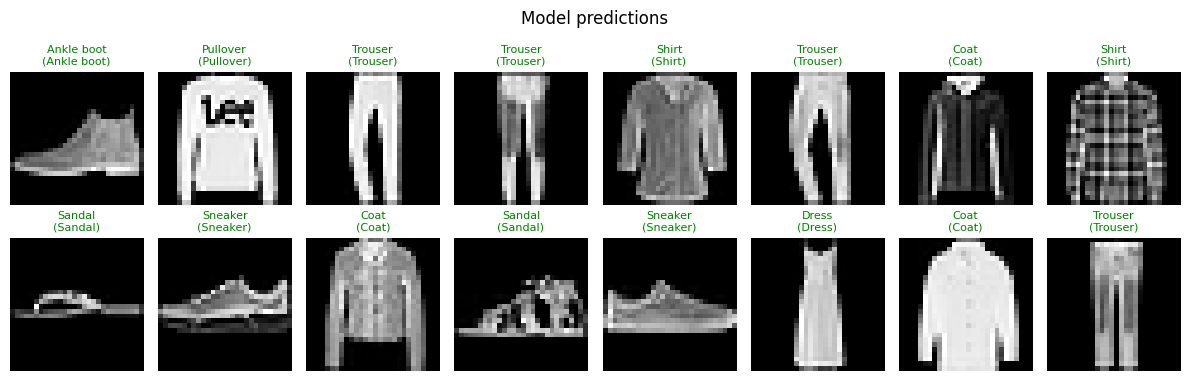

In [10]:
model.eval()
images, labels = next(iter(test))

with torch.no_grad():
    logits = model(images[:16].to(device))
    predictions = logits.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    image = images[i].squeeze() * 0.5 + 0.5
    ax.imshow(image, cmap='gray')
    predicted = class_names[predictions[i]]
    true = class_names[labels[i]]
    correct = predicted == true
    ax.set_title(f'{predicted}\n({true})', color='green' if correct else 'red', fontsize=8)
    ax.axis('off')

plt.suptitle('Model predictions')
plt.tight_layout()
plt.show()

## Confusion matrix

Accuracy gives us one number. A confusion matrix shows **which classes the model confuses with each other**.

The following code computes and visualizes a confusion matrix for the test set, showing how often each true Fashion-MNIST class is correctly classified or confused with another class.

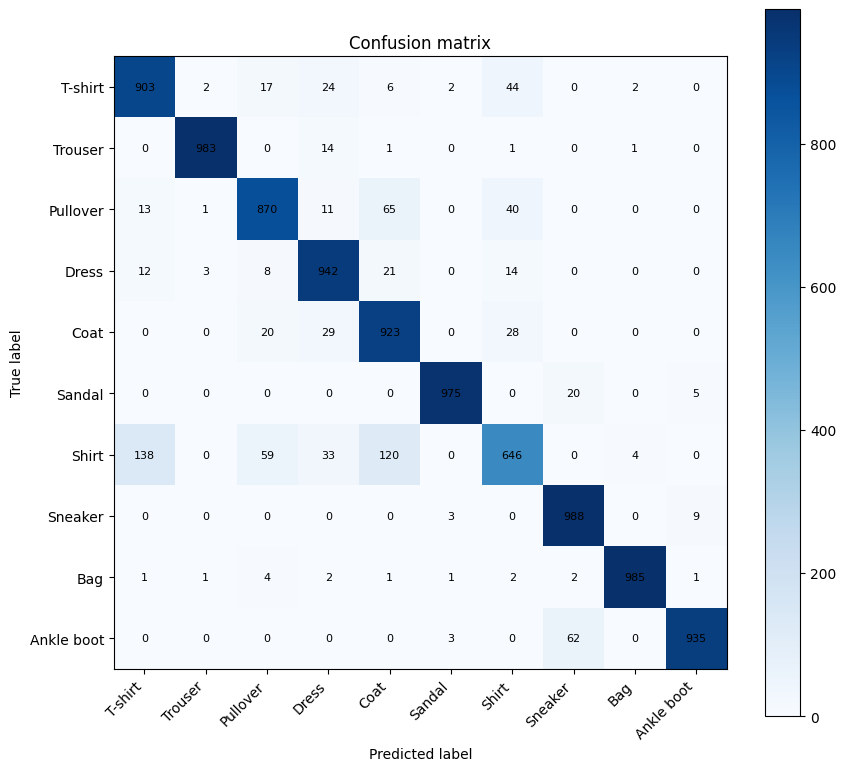

In [11]:
confusion = torch.zeros(10, 10, dtype=torch.int64)

model.eval()
with torch.no_grad():
    for x, y in test:
        x = x.to(device)
        predicted = model(x).argmax(dim=1).cpu()
        for true_label, predicted_label in zip(y, predicted):
            confusion[true_label, predicted_label] += 1

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(confusion, cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set_xticks(range(10), class_names, rotation=45, ha='right')
ax.set_yticks(range(10), class_names)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion matrix')

for i in range(10):
    for j in range(10):
        ax.text(j, i, int(confusion[i, j]), ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

The color intensity represents how many images are counted in each cell. A darker shade means that a larger number of images received that true–predicted label combination, while a lighter shade means fewer images. The numbers in the cells give the exact count.

### Reflection

Look at the confusion matrix and answer:

1. Which class is recognized most accurately?
2. Which two classes are confused most often?
3. Why might those classes be visually difficult to distinguish?

## Visualizing convolutional feature maps

The first convolutional layer transforms the input image into several feature maps. These maps show the responses of different learned filters.

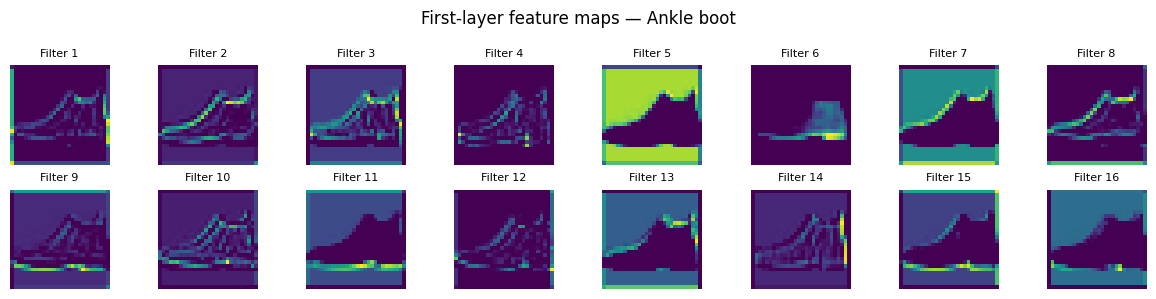

In [12]:
model.eval()
image = images[0:1].to(device)

with torch.no_grad():
    feature_maps = model.features[2](model.features[1](model.features[0](image)))

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[0, i].cpu(), cmap='viridis')
    ax.set_title(f'Filter {i + 1}', fontsize=8)
    ax.axis('off')

plt.suptitle(f'First-layer feature maps — {class_names[labels[0]]}')
plt.tight_layout()
plt.show()

The above code visualizes the feature maps produced by the first convolutional layer for one input image. Each feature map shows which parts of the image activate a particular learned filter, helping us see what kinds of visual patterns the CNN is detecting.

## Final Takeaway

The CNN in this exercise combines several building blocks, each with a specific role in learning from images:

**Input image → Convolution → Batch Normalization → ReLU → Max Pooling → ×3 → Flatten → Fully Connected Layer → Dropout → Classification**

The three convolutional blocks progressively transform the image: the number of feature channels increases from **32 → 64 → 128**, while the spatial dimensions decrease from **28×28 → 14×14 → 7×7 → 3×3**. This allows the network to move from detecting simpler visual patterns toward more complex and useful representations.

The final fully connected layers use these learned representations to make the classification decision. **Batch normalization** helps stabilize the learning process, while **dropout** helps the model avoid relying too heavily on individual features.

Overall, this architecture illustrates the central idea behind CNNs: **learn useful visual representations automatically through convolutional layers, then use those representations to perform classification.**